## 1. 이산 확률변수 - 두 주사위 합의 PMF와 CDF

2개의 주사위를 동시에 던졌을 때 나오는 합(2~12)을 확률변수로 설정하여,
**확률질량함수(PMF)**와 **누적분포함수(CDF)**를 시각화한 그래프

- **왼쪽 (PMF)**: 각 합이 나올 확률을 막대그래프로 표현. 합이 7일 때 확률이 가장 높고(0.167), 양쪽 끝으로 갈수록 확률이 낮아지는 대칭 구조
- **오른쪽 (CDF)**: 특정 값 이하가 나올 누적확률을 계단 함수로 표현. P(X≤2)=0.028에서 시작하여 P(X≤12)=1.000까지 단조 증가


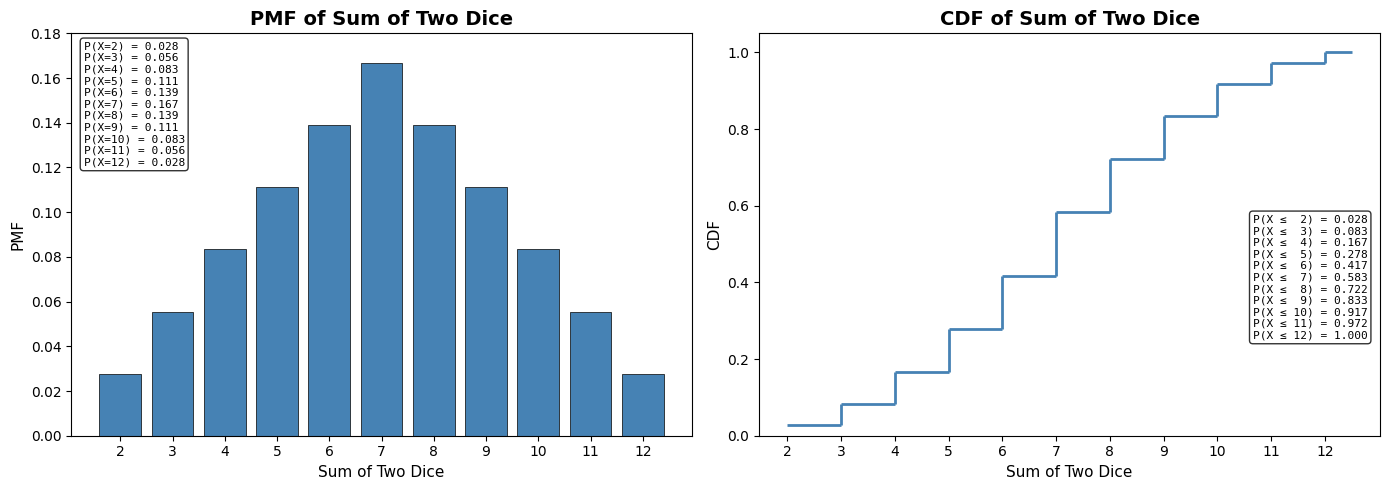


=== PMF (확률질량함수) ===
  P(X= 2) = 0.028
  P(X= 3) = 0.056
  P(X= 4) = 0.083
  P(X= 5) = 0.111
  P(X= 6) = 0.139
  P(X= 7) = 0.167
  P(X= 8) = 0.139
  P(X= 9) = 0.111
  P(X=10) = 0.083
  P(X=11) = 0.056
  P(X=12) = 0.028

=== CDF (누적분포함수) ===
  P(X ≤  2) = 0.028
  P(X ≤  3) = 0.083
  P(X ≤  4) = 0.167
  P(X ≤  5) = 0.278
  P(X ≤  6) = 0.417
  P(X ≤  7) = 0.583
  P(X ≤  8) = 0.722
  P(X ≤  9) = 0.833
  P(X ≤ 10) = 0.917
  P(X ≤ 11) = 0.972
  P(X ≤ 12) = 1.000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# 2개 주사위의 합 계산
outcomes = [d1 + d2 for d1, d2 in product(range(1, 7), range(1, 7))]
total = len(outcomes)  # 36

# PMF 계산
x_values = list(range(2, 13))
pmf = [outcomes.count(x) / total for x in x_values]

# CDF 계산
cdf = np.cumsum(pmf)

# 그래프 그리기
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- PMF ---
ax1 = axes[0]
ax1.bar(x_values, pmf, color='steelblue', edgecolor='black', linewidth=0.5)
ax1.set_title('PMF of Sum of Two Dice', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sum of Two Dice', fontsize=11)
ax1.set_ylabel('PMF', fontsize=11)
ax1.set_xticks(x_values)
ax1.set_ylim(0, 0.18)

# PMF 확률값 텍스트
pmf_text = '\n'.join([f'P(X={x}) = {p:.3f}' for x, p in zip(x_values, pmf)])
ax1.text(0.02, 0.98, pmf_text, transform=ax1.transAxes,
         fontsize=8, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- CDF ---
ax2 = axes[1]
# 계단 함수 형태로 그리기
for i, x in enumerate(x_values):
    x_start = x - 0.5 if i == 0 else x
    x_end = x + 1 if i < len(x_values) - 1 else x + 0.5
    ax2.hlines(cdf[i], x, x_end, colors='steelblue', linewidth=2)
    if i < len(x_values) - 1:
        ax2.vlines(x_values[i + 1], cdf[i], cdf[i + 1], colors='steelblue', linewidth=2)

ax2.set_title('CDF of Sum of Two Dice', fontsize=14, fontweight='bold')
ax2.set_xlabel('Sum of Two Dice', fontsize=11)
ax2.set_ylabel('CDF', fontsize=11)
ax2.set_xticks(x_values)
ax2.set_ylim(0, 1.05)

# CDF 확률값 텍스트
cdf_text = '\n'.join([f'P(X ≤ {x:2d}) = {c:.3f}' for x, c in zip(x_values, cdf)])
ax2.text(0.98, 0.55, cdf_text, transform=ax2.transAxes,
         fontsize=8, verticalalignment='top', horizontalalignment='right',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# 결과 출력
print("\n=== PMF (확률질량함수) ===")
for x, p in zip(x_values, pmf):
    print(f"  P(X={x:2d}) = {p:.3f}")

print("\n=== CDF (누적분포함수) ===")
for x, c in zip(x_values, cdf):
    print(f"  P(X ≤ {x:2d}) = {c:.3f}")

## 2. 베르누이 분포 - 공정한 동전 100번 시행

성공확률 p=0.5인 **베르누이 분포**를 가정하고 100번 시행한 결과를 시각화한 그래프

- **왼쪽**: 100번의 개별 시행 결과를 막대로 표시합니다. 파란색은 성공(1), 빨간색은 실패(0)입니다.
- **오른쪽**: 성공과 실패의 총 횟수를 비교하는 막대그래프입니다. p=0.5이므로 대략 50:50 근처 결과가 나오지만, 실행할 때마다 약간의 차이가 있음


=== 베르누이 분포 (p=0.5) 100번 시행 결과 ===
  성공(1): 48번
  실패(0): 52번


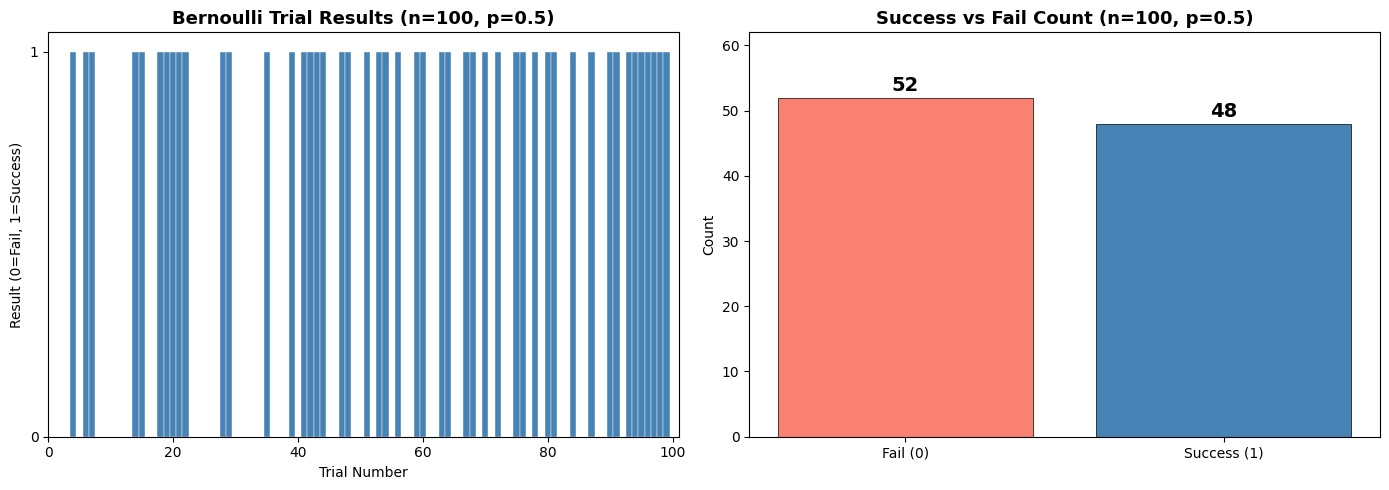

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli

# 베르누이 분포: 성공확률 p=0.5, 100번 시행
p = 0.5
n_trials = 100

# 100번 시행 결과 생성
results = bernoulli.rvs(p, size=n_trials)

# 성공/실패 횟수
n_success = results.sum()
n_fail = n_trials - n_success

print(f"=== 베르누이 분포 (p={p}) 100번 시행 결과 ===")
print(f"  성공(1): {n_success}번")
print(f"  실패(0): {n_fail}번")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- (1) 100번 시행 결과 시각화 ---
ax1 = axes[0]
colors = ['salmon' if r == 0 else 'steelblue' for r in results]
ax1.bar(range(1, n_trials + 1), results, color=colors, width=1.0, edgecolor='white', linewidth=0.3)
ax1.set_title(f'Bernoulli Trial Results (n={n_trials}, p={p})', fontsize=13, fontweight='bold')
ax1.set_xlabel('Trial Number')
ax1.set_ylabel('Result (0=Fail, 1=Success)')
ax1.set_yticks([0, 1])
ax1.set_xlim(0, n_trials + 1)

# --- (2) 성공/실패 비율 막대그래프 ---
ax2 = axes[1]
bars = ax2.bar(['Fail (0)', 'Success (1)'], [n_fail, n_success],
               color=['salmon', 'steelblue'], edgecolor='black', linewidth=0.5)
ax2.set_title(f'Success vs Fail Count (n={n_trials}, p={p})', fontsize=13, fontweight='bold')
ax2.set_ylabel('Count')

# 막대 위에 숫자 표시
for bar, count in zip(bars, [n_fail, n_success]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{count}', ha='center', fontsize=14, fontweight='bold')

ax2.set_ylim(0, max(n_fail, n_success) + 10)

plt.tight_layout()
plt.show()


## 3. 이항분포 시뮬레이션 - 동전 100번 던지기를 10,000번 반복

동전을 100번 던져서 앞면이 나올 횟수를, **10,000번 반복** 시행하여 빈도를 시각화한 그래프

- **빨간 히스토그램**: 10,000번 시뮬레이션에서 나온 앞면 횟수의 빈도 분포
- **흰색 곡선**: 정규분포 근사 곡선 (μ=50, σ=5)
- 이항분포의 시행 횟수가 충분히 크면 정규분포에 수렴하는 **중심극한정리**를 확인할 수 있음


=== 이항분포 시뮬레이션 ===
  동전 100번 던지기를 10000번 반복
  평균 앞면 횟수: 49.93
  표준편차: 5.00


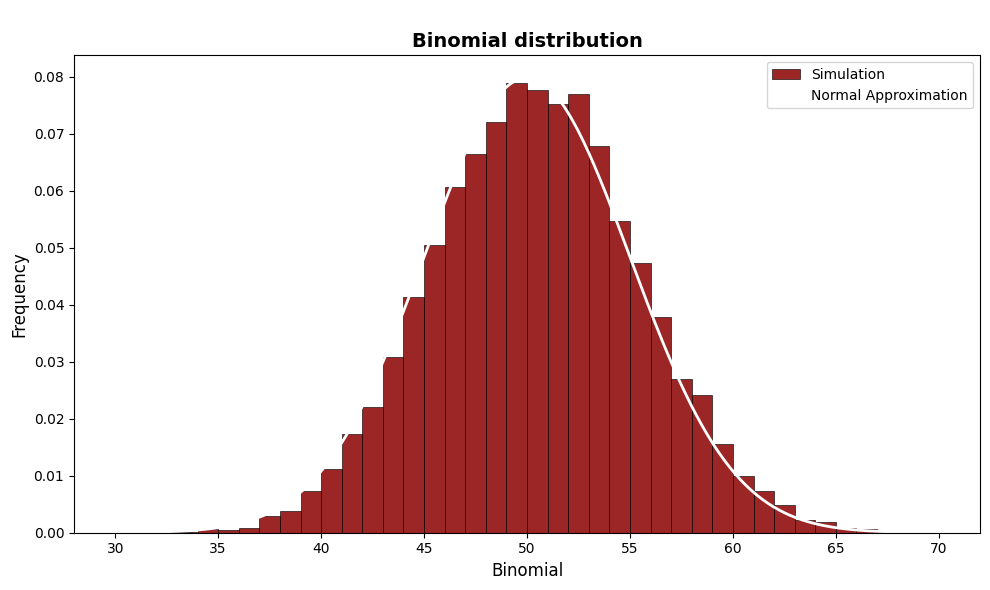

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

# 동전을 100번 던져서 앞면 나올 횟수를, 10000번 반복 시행
n = 100        # 동전 던지기 횟수
p = 0.5        # 성공확률 (앞면)
simulations = 10000  # 시행 반복 횟수

# 시뮬레이션
results = binom.rvs(n, p, size=simulations)

print(f"=== 이항분포 시뮬레이션 ===")
print(f"  동전 {n}번 던지기를 {simulations}번 반복")
print(f"  평균 앞면 횟수: {results.mean():.2f}")
print(f"  표준편차: {results.std():.2f}")

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))

# 히스토그램 (빈도 → density로 정규화)
ax.hist(results, bins=range(30, 72), density=True, color='darkred',
        edgecolor='black', linewidth=0.5, alpha=0.85, label='Simulation')

# 정규분포 곡선 오버레이
mu = n * p          # 평균 = 50
sigma = np.sqrt(n * p * (1 - p))  # 표준편차 = 5
x = np.linspace(30, 70, 300)
ax.plot(x, norm.pdf(x, mu, sigma), 'w-', linewidth=2, label='Normal Approximation')

ax.set_title('\nBinomial distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Binomial', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_xlim(28, 72)
ax.legend()

plt.tight_layout()
plt.show()


## 4. 이항분포의 정규분포 수렴 과정 (N=1, 10, 100)

N이 커질수록 이항분포가 정규분포에 수렴하는 과정을 3단계로 보여주는 그래프

- **왼쪽 (N=1)**: 베르누이 분포. 0과 1 두 값에 각각 0.5의 확률이 집중됩니다.
- **가운데 (N=10)**: 이항분포. 종 모양이 서서히 나타나기 시작
- **오른쪽 (N=100)**: 이항분포 + 빨간 정규분포 곡선. 두 분포가 거의 완벽하게 일치하여, **N이 충분히 크면 이항분포는 정규분포로 근사**할 수 있음을 시각적으로 확인


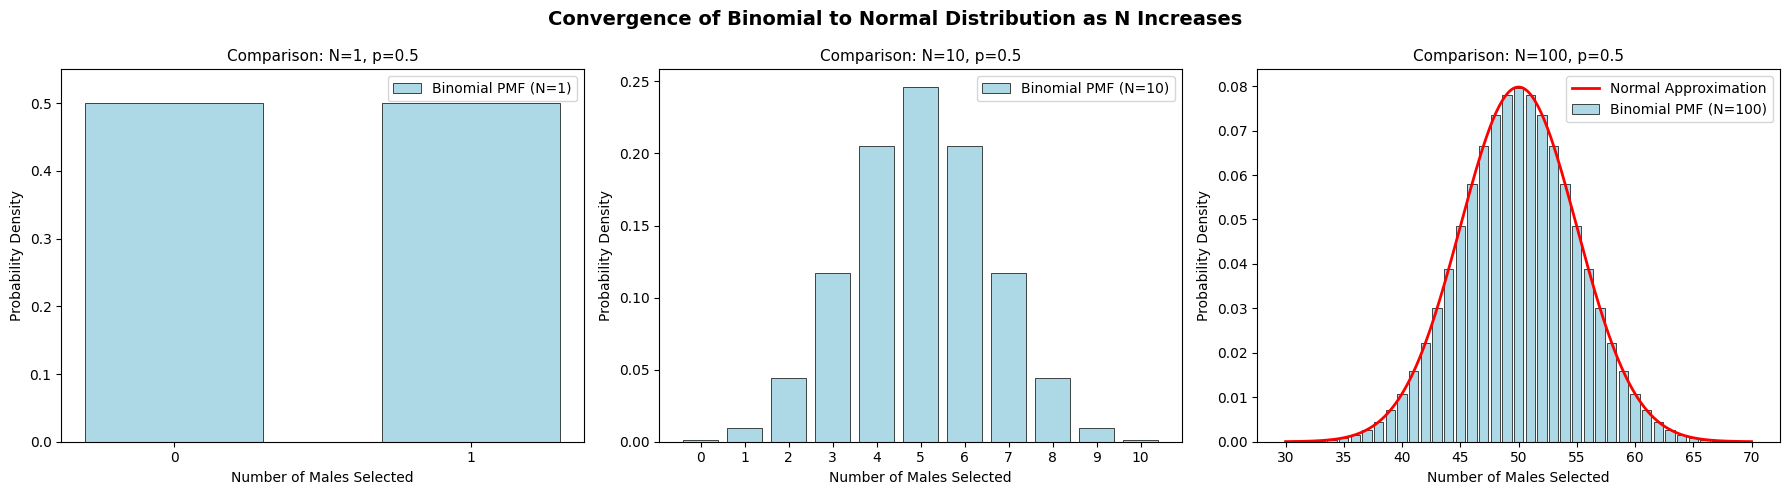

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, bernoulli, norm

p = 0.5

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Convergence of Binomial to Normal Distribution as N Increases',
             fontsize=14, fontweight='bold')

# --- (1) N=1, p=0.5 (베르누이) ---
ax1 = axes[0]
x1 = [0, 1]
pmf1 = [bernoulli.pmf(k, p) for k in x1]
ax1.bar(x1, pmf1, color='lightblue', edgecolor='black', linewidth=0.5,
        width=0.6, label='Binomial PMF (N=1)')
ax1.set_title(f'Comparison: N=1, p={p}', fontsize=11)
ax1.set_xlabel('Number of Males Selected')
ax1.set_ylabel('Probability Density')
ax1.set_xticks(x1)
ax1.set_ylim(0, 0.55)
ax1.legend()

# --- (2) N=10, p=0.5 ---
N10 = 10
ax2 = axes[1]
x10 = list(range(N10 + 1))
pmf10 = [binom.pmf(k, N10, p) for k in x10]
ax2.bar(x10, pmf10, color='lightblue', edgecolor='black', linewidth=0.5,
        label=f'Binomial PMF (N={N10})')
ax2.set_title(f'Comparison: N={N10}, p={p}', fontsize=11)
ax2.set_xlabel('Number of Males Selected')
ax2.set_ylabel('Probability Density')
ax2.set_xticks(x10)
ax2.legend()

# --- (3) N=100, p=0.5 + 정규분포 근사 ---
N100 = 100
ax3 = axes[2]
mu = N100 * p            # 50
sigma = np.sqrt(N100 * p * (1 - p))  # 5

x100 = np.arange(30, 71)
pmf100 = [binom.pmf(k, N100, p) for k in x100]
ax3.bar(x100, pmf100, color='lightblue', edgecolor='black', linewidth=0.5,
        label=f'Binomial PMF (N={N100})')

# 정규분포 곡선
x_norm = np.linspace(30, 70, 300)
y_norm = norm.pdf(x_norm, mu, sigma)
ax3.plot(x_norm, y_norm, 'r-', linewidth=2, label='Normal Approximation')

ax3.set_title(f'Comparison: N={N100}, p={p}', fontsize=11)
ax3.set_xlabel('Number of Males Selected')
ax3.set_ylabel('Probability Density')
ax3.legend()

plt.tight_layout()
plt.show()

## 5. 골턴 보드 시뮬레이션 - 동전 10개, 1490회 시행

10개의 동전을 한꺼번에 던져 각각 H(앞면)=1, T(뒷면)=-1로 합산한 뒤 5를 차감하여 Value를 구함
이 시행을 **1490회 반복**하여 빈도를 히스토그램으로 나타냄

- **파란 막대**: 시뮬레이션 결과의 빈도 분포
- **파란 곡선**: 이항분포 이론 곡선을 부드럽게 보간한 것
- Value=0 근처에 가장 많이 몰리는 종 모양이 나타나며, 이는 골턴 보드(Galton Board) 실험과 동일한 원리


=== 골턴 보드 시뮬레이션 결과 ===
  동전 10개, 1490회 시행

   Value | Frequency
  -------+----------
      -5 |         2
      -4 |        21
      -3 |        69
      -2 |       175
      -1 |       315
       0 |       369
       1 |       293
       2 |       175
       3 |        59
       4 |        12
       5 |         0


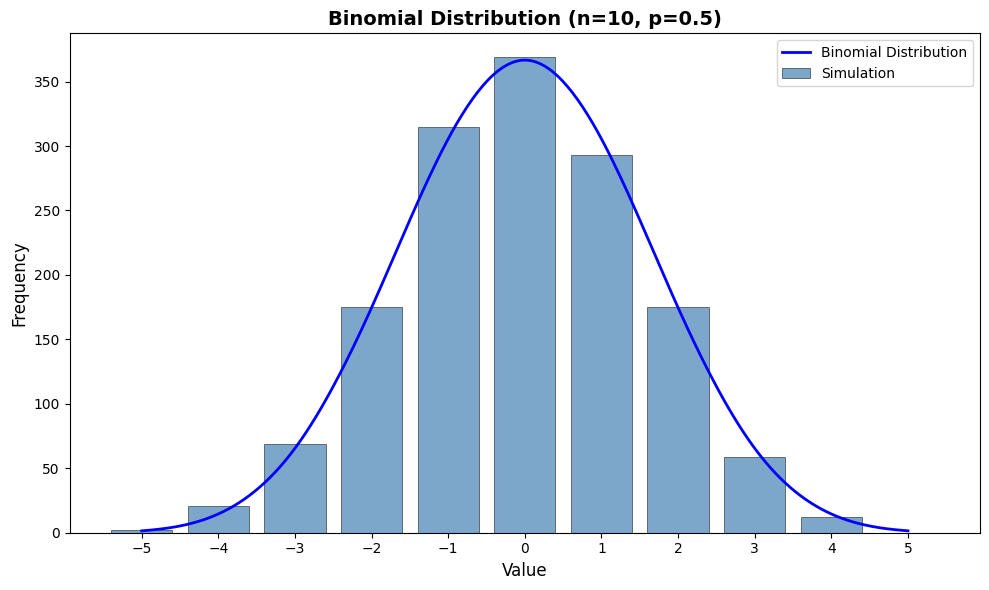

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
from scipy.interpolate import make_interp_spline

# ============================================================
# 골턴 보드 시뮬레이션
# 10개의 동전을 한꺼번에 던지기 (H:1, T:-1)
# 그 합에서 5를 차감 → value = (앞면 개수) - 5
# 이 시행을 1490회 반복
# ============================================================

n_coins = 10       # 동전 개수
n_trials = 1490    # 시행 횟수
p = 0.5            # 앞면 확률

# 시뮬레이션
heads_count = np.random.binomial(n_coins, p, size=n_trials)
values = heads_count - 5  # 앞면 개수 - 5 (= H*1 + T*(-1)에서 5 차감과 동일)

# Value별 Frequency 계산
unique_vals = np.arange(-5, 6)  # -5 ~ 5
freq = [np.sum(values == v) for v in unique_vals]

print("=== 골턴 보드 시뮬레이션 결과 ===")
print(f"  동전 {n_coins}개, {n_trials}회 시행\n")
print(f"  {'Value':>6} | {'Frequency':>9}")
print(f"  {'-'*6}-+-{'-'*9}")
for v, f in zip(unique_vals, freq):
    print(f"  {v:>6} | {f:>9}")

# ============================================================
# 시각화
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

# 히스토그램
ax.bar(unique_vals, freq, color='steelblue', edgecolor='black',
       linewidth=0.5, alpha=0.7, width=0.8, label='Simulation')

# 이항분포 이론 곡선 오버레이 (부드러운 곡선)
x_binom = np.arange(0, n_coins + 1)
pmf_binom = binom.pmf(x_binom, n_coins, p) * n_trials
x_shifted = x_binom - 5

spl = make_interp_spline(x_shifted, pmf_binom, k=3)
x_smooth = np.linspace(-5, 5, 300)
y_smooth = spl(x_smooth)

ax.plot(x_smooth, y_smooth, 'b-', linewidth=2, label='Binomial Distribution')

ax.set_title(f'Binomial Distribution (n={n_coins}, p={p})', fontsize=14, fontweight='bold')
ax.set_xlabel('Value', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_xticks(unique_vals)
ax.legend()

plt.tight_layout()
plt.show()

## 6. 중심극한정리(CLT) 시각화

### 왼쪽 열 - 개별 데이터 분포

1. **Uniform 분포**: 0~10 사이에서 모든 값이 동일한 확률로 나타나므로, 히스토그램이 평평한 직사각형 모양이다.
2. **Exponential 분포**: 0 근처에 데이터가 집중되고 오른쪽으로 긴 꼬리가 늘어진다. 비대칭(skewed)이며 heavy tail 특성을 가진다.
3. **이상치 포함 데이터**: 평균 5 부근에 대부분의 데이터가 몰려 있지만, 평균 20 부근에 소수의 이상치(outliers)가 별도의 봉우리를 형성한다.

### 오른쪽 열 - 표본 평균의 분포

- 각 분포에서 30개씩 표본을 뽑아 평균을 구하는 작업을 1,000번 반복한 결과이다.
- 원본 데이터가 어떤 분포이든 상관없이, 표본 평균의 분포는 모두 종 모양의 정규분포에 수렴한다.
- 빨간 곡선은 이론적 정규분포 곡선이며, 파란 히스토그램과 거의 일치하는 것을 확인할 수 있다.
- 이것이 중심극한정리의 핵심으로, 표본 크기가 충분히 크면 원래 분포와 무관하게 표본 평균은 정규분포를 따른다.

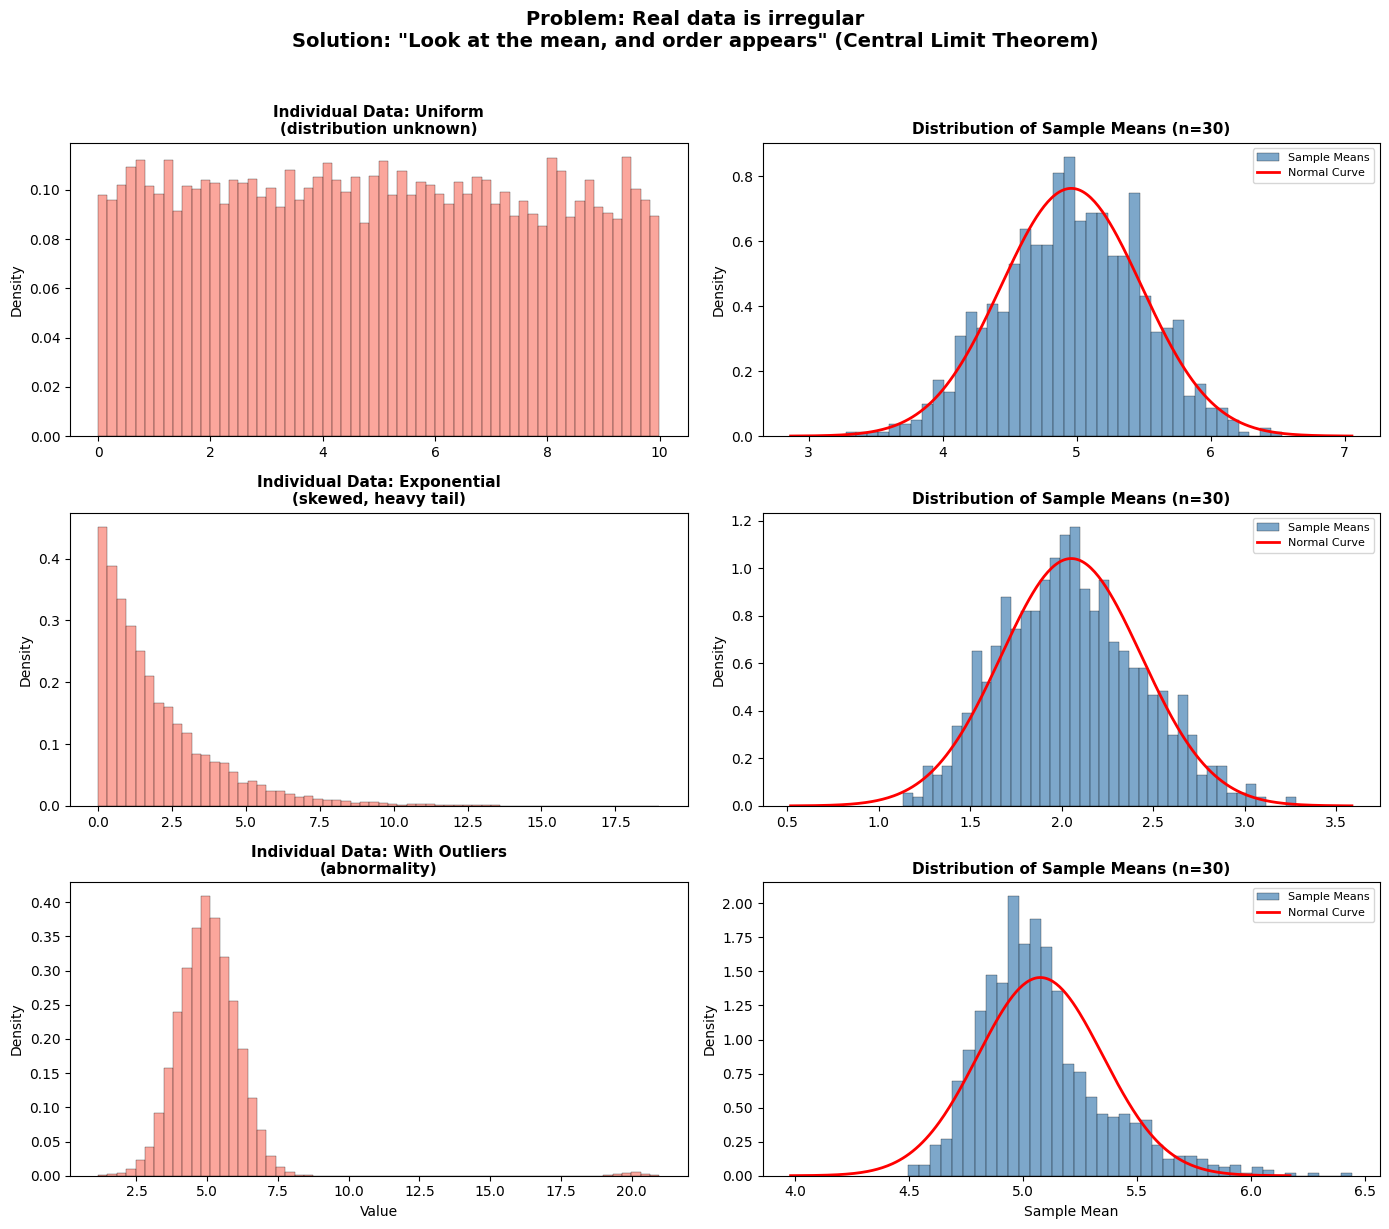

  Result: Central Limit Theorem Demonstration

  [Uniform (distribution unknown)]
    Population Mean:    4.9416
    Population Std:     2.8762
    Sample Means Mean:  4.9666
    Sample Means Std:   0.5302

  [Exponential (skewed, heavy tail)]
    Population Mean:    2.0371
    Population Std:     2.0413
    Sample Means Mean:  2.0323
    Sample Means Std:   0.3714

  [With Outliers (abnormality)]
    Population Mean:    5.0781
    Population Std:     1.4493
    Sample Means Mean:  5.0757
    Sample Means Std:   0.2611

  Key Insight: Regardless of the original distribution,
  the distribution of sample means approaches Normal!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ============================================================
# 문제 풀이: 현실 데이터는 왜 어려운가? → 평균이 문제를 해결한다.
#
# - 분포를 모른다 (uniform, exponential 등)
# - 이상치(outliers) 존재
# - 정규분포 아님 (skewed, heavy tail)
#
# 핵심 메시지: "평균을 보면 질서가 보인다" (중심극한정리, CLT)
# ============================================================

np.random.seed(42)

# === 설정 ===
n_samples = 10000      # 전체 데이터 수
sample_size = 30       # 한 번에 뽑는 표본 크기
n_means = 1000         # 표본 평균을 구하는 횟수

# === 3가지 "어려운" 분포 ===
distributions = {
    'Uniform\n(distribution unknown)': np.random.uniform(0, 10, n_samples),
    'Exponential\n(skewed, heavy tail)': np.random.exponential(scale=2.0, size=n_samples),
    'With Outliers\n(abnormality)': np.concatenate([
        np.random.normal(5, 1, n_samples - 50),
        np.random.normal(20, 0.5, 50)   # 이상치 50개
    ])
}

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle(
    'Problem: Real data is irregular\n'
    'Solution: "Look at the mean, and order appears" (Central Limit Theorem)',
    fontsize=14, fontweight='bold', y=1.02
)

for idx, (name, data) in enumerate(distributions.items()):
    # --- 왼쪽: 개별 데이터 (불규칙) ---
    ax_left = axes[idx][0]
    ax_left.hist(data, bins=60, density=True, color='salmon',
                 edgecolor='black', linewidth=0.3, alpha=0.7)
    ax_left.set_title(f'Individual Data: {name}', fontsize=11, fontweight='bold')
    ax_left.set_ylabel('Density')
    if idx == 2:
        ax_left.set_xlabel('Value')

    # --- 오른쪽: 표본 평균의 분포 (안정적 → 정규분포) ---
    ax_right = axes[idx][1]

    # 표본 평균 n_means번 계산
    sample_means = [np.mean(np.random.choice(data, size=sample_size)) for _ in range(n_means)]

    ax_right.hist(sample_means, bins=40, density=True, color='steelblue',
                  edgecolor='black', linewidth=0.3, alpha=0.7, label='Sample Means')

    # 정규분포 곡선 오버레이
    mu = np.mean(sample_means)
    sigma = np.std(sample_means)
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
    ax_right.plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Curve')

    ax_right.set_title(f'Distribution of Sample Means (n={sample_size})', fontsize=11, fontweight='bold')
    ax_right.set_ylabel('Density')
    ax_right.legend(fontsize=8)
    if idx == 2:
        ax_right.set_xlabel('Sample Mean')

plt.tight_layout()
plt.show()

# === 결과 요약 출력 ===
print("=" * 60)
print("  Result: Central Limit Theorem Demonstration")
print("=" * 60)
for name, data in distributions.items():
    sample_means = [np.mean(np.random.choice(data, size=sample_size)) for _ in range(n_means)]
    print(f"\n  [{name.replace(chr(10), ' ')}]")
    print(f"    Population Mean:    {np.mean(data):.4f}")
    print(f"    Population Std:     {np.std(data):.4f}")
    print(f"    Sample Means Mean:  {np.mean(sample_means):.4f}")
    print(f"    Sample Means Std:   {np.std(sample_means):.4f}")
print("\n" + "=" * 60)
print("  Key Insight: Regardless of the original distribution,")
print("  the distribution of sample means approaches Normal!")
print("=" * 60)